   reviews  spam_words  fake_reviews
0       10           1             1
1       20           2             2
2       30           3             3
3       40           4             4
4       50           5             5


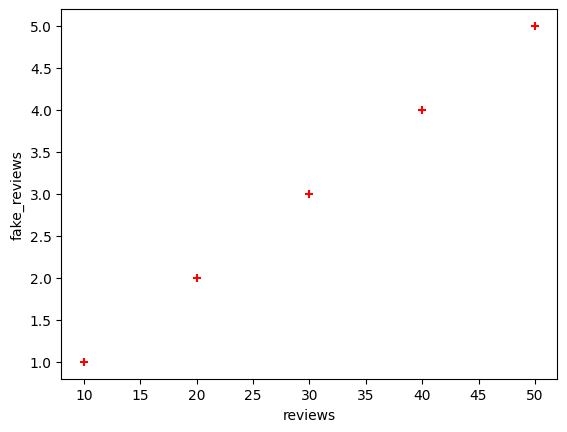


Prediction for [25 reviews, 3 spam words]
[2.5049505]

Coefficient:
[0.0990099  0.00990099]

Intercept:
-3.1086244689504383e-15

Prediction Table:
   reviews  spam_words  predicted_fake_reviews
0       15           1                1.495050
1       35           3                3.495050
2       60           5                5.990099

CSV File Saved Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [12]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

# create dataset
df = pd.DataFrame({
    'reviews': [10,20,30,40,50],
    'spam_words': [1,2,3,4,5],
    'fake_reviews': [1,2,3,4,5]
})

print(df)

# graph
%matplotlib inline
plt.xlabel('reviews')
plt.ylabel('fake_reviews')
plt.scatter(df.reviews, df.fake_reviews, color='red', marker='+')
plt.show()

# input data
new_df = df.drop('fake_reviews', axis='columns')

# output data
fake = df.fake_reviews

# create model
reg = linear_model.LinearRegression()

# train model
reg.fit(new_df, fake)

# prediction
print("\nPrediction for [25 reviews, 3 spam words]")
print(reg.predict([[25,3]]))

# coefficient
print("\nCoefficient:")
print(reg.coef_)

# intercept
print("\nIntercept:")
print(reg.intercept_)

# multiple predictions
test_df = pd.DataFrame({
    'reviews': [15,35,60],
    'spam_words': [1,3,5]
})

p = reg.predict(test_df)

# add prediction column
test_df['predicted_fake_reviews'] = p

print("\nPrediction Table:")
print(test_df)

# save csv
test_df.to_csv("fake_review_prediction.csv", index=False)

print("\nCSV File Saved Successfully")